# Face Recognition con SVD - Labeled Faces in the Wild (LFW)

Questo notebook implementa lo stesso sistema di riconoscimento facciale su un dataset più complesso e realistico:
- **Dataset**: Labeled Faces in the Wild (LFW) - foto di celebrità in condizioni naturali
- **Sfide**: variazioni di illuminazione, pose, espressioni, qualità immagini
- **Confronto** con risultati su Olivetti per valutare robustezza

---

## 1. Setup e Import

In [32]:
# Import librerie
import time
import numpy as np
import warnings
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Import moduli custom
from src.data_loader import DataLoader
from src.svd_engine import SVDReducerEngine
from src.recognizer import FaceRecognizer
from src.visualizer import Visualizer

# Configurazione
warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)

# Dizionario per tracciare i tempi
execution_times = {}
performance_metrics = {}

## 2. Caricamento Dataset LFW

LFW è significativamente più complesso di Olivetti:
- **Condizioni reali**: foto non controllate, illuminazione variabile
- **Variabilità**: diverse pose, espressioni, età
- **Qualità**: risoluzione e qualità variabili

In [2]:
# Inizializza visualizer
viz = Visualizer(path=r"result/lfw")

# Carica dataset LFW
start_time = time.time()
dataset = DataLoader(min_faces_per_person=60, resize=0.4)
dataset.X, dataset.X_flat, dataset.y = dataset.load_lfw_data()
execution_times['data_loading'] = time.time() - start_time

# Statistiche dataset
print("=" * 60)
print("STATISTICHE DATASET LFW")
print("=" * 60)
print(f"Shape immagini originali: {dataset.X.shape}")
print(f"Shape immagini flatten: {dataset.X_flat.shape}")
print(f"Numero totale immagini: {len(dataset.y)}")
print(f"Numero persone uniche: {len(np.unique(dataset.y))}")
print(f"Risoluzione: {dataset.X.shape[1]}x{dataset.X.shape[2]} pixels")
print(f"Dimensione feature space: {dataset.X_flat.shape[1]}")
print(f"Tempo di caricamento: {execution_times['data_loading']:.4f}s")

# Distribuzione immagini per persona
unique, counts = np.unique(dataset.y, return_counts=True)
print(f"\nImmagini per persona:")
print(f"  Media: {np.mean(counts):.1f}")
print(f"  Min: {np.min(counts)}")
print(f"  Max: {np.max(counts)}")
print("=" * 60)

STATISTICHE DATASET LFW
Shape immagini originali: (1348, 50, 37)
Shape immagini flatten: (1348, 1850)
Numero totale immagini: 1348
Numero persone uniche: 8
Risoluzione: 50x37 pixels
Dimensione feature space: 1850
Tempo di caricamento: 0.1450s

Immagini per persona:
  Media: 168.5
  Min: 60
  Max: 530


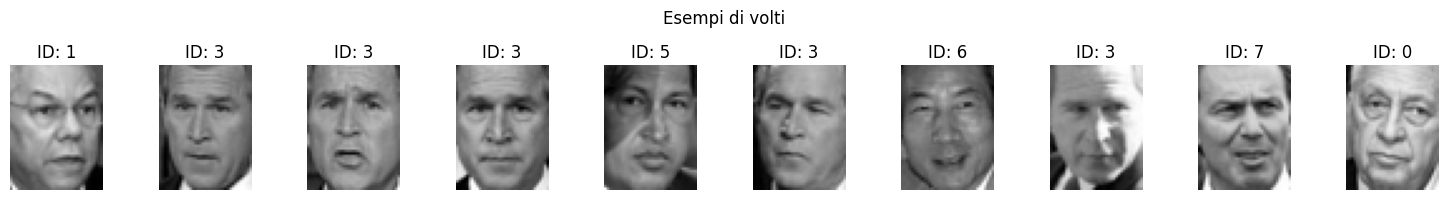

In [3]:
# Visualizza campioni
viz.plot_sample_faces(dataset.X, dataset.y, n_samples=10)

## 3. Pre-processing: Centratura Dati

In [4]:
start_time = time.time()
dataset.X_centered = dataset.center_data()
execution_times['centering'] = time.time() - start_time

print(f"Shape dati centrati: {dataset.X_centered.shape}")
print(f"Media dei dati centrati: {np.mean(dataset.X_centered):.10f} (dovrebbe essere ~0)")
print(f"Deviazione standard: {np.std(dataset.X_centered):.4f}")
print(f"Range valori: [{np.min(dataset.X_centered):.4f}, {np.max(dataset.X_centered):.4f}]")
print(f"Tempo di centratura: {execution_times['centering']:.4f}s")

Shape di self.X_flat: (1348, 1850)
Shape dati centrati: (1348, 1850)
Media dei dati centrati: -0.0000000016 (dovrebbe essere ~0)
Deviazione standard: 0.1488
Range valori: [-0.6109, 0.6913]
Tempo di centratura: 0.0000s


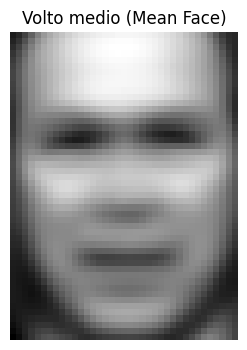

In [5]:
# Visualizza volto medio
viz.plot_mean_face_lfw(dataset.mean_face, dataset.X)

## 4. Singular Value Decomposition (SVD)

**Nota**: LFW ha dimensionalità molto più alta di Olivetti, quindi SVD sarà più costosa computazionalmente.

In [6]:
start_time = time.time()
svd_reducer = SVDReducerEngine(energy_threshold=0.95)
U, S, VT, energy = svd_reducer.compute_full_svd(dataset.X_centered)
execution_times['full_svd'] = time.time() - start_time

print("=" * 60)
print("RISULTATI SVD - LFW")
print("=" * 60)
print(f"Shape U: {U.shape}")
print(f"Shape S (valori singolari): {S.shape}")
print(f"Shape V^T (eigenfaces): {VT.shape}")
print(f"\nPrimi 10 valori singolari:")
print(S[:10])
print(f"\nRapporto primo/ultimo valore singolare: {S[0]/S[-1]:.2e}")
print(f"\nTempo calcolo SVD: {execution_times['full_svd']:.2f}s")
print("=" * 60)

performance_metrics['svd_time'] = execution_times['full_svd']

RISULTATI SVD - LFW
Shape U: (1348, 1348)
Shape S (valori singolari): (1348,)
Shape V^T (eigenfaces): (1348, 1850)

Primi 10 valori singolari:
[107.819   87.0397  61.5819  56.6432  51.6149  39.2917  36.1362  33.1384
  32.1751  31.5507]

Rapporto primo/ultimo valore singolare: 4.72e+05

Tempo calcolo SVD: 1.89s


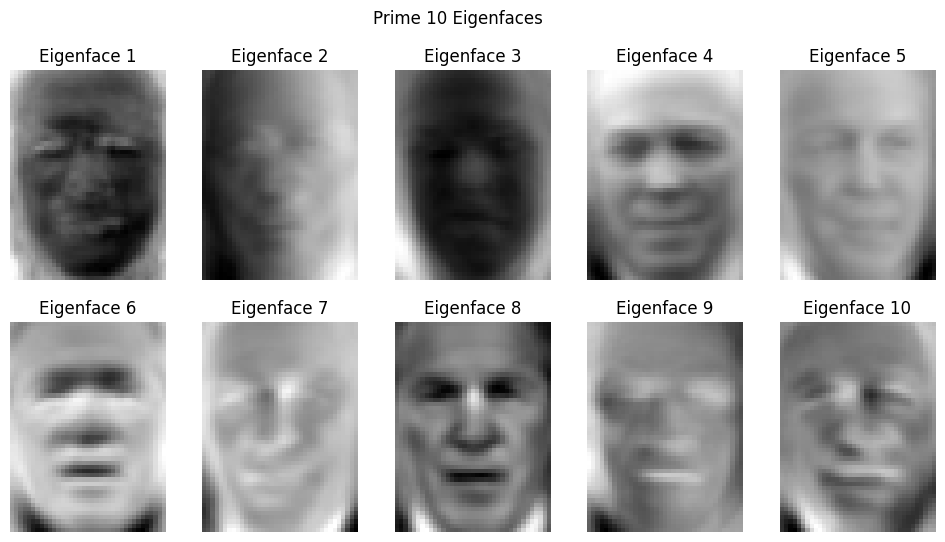

In [7]:
# Visualizza eigenfaces
viz.plot_eigenfaces_lfw(VT, dataset.X, n_components=10)

## 5. Selezione Componenti e Riduzione Dimensionale

In [8]:
n_components = svd_reducer.select_components()

print("=" * 60)
print("ANALISI RIDUZIONE DIMENSIONALE")
print("=" * 60)
print(f"Soglia energia: {svd_reducer.energy_threshold * 100}%")
print(f"Componenti selezionate: {n_components}")
print(f"Energia effettiva: {energy[n_components - 1] * 100:.2f}%")
print(f"\nCompressione:")
print(f"  Dimensioni originali: {dataset.X_flat.shape[1]}")
print(f"  Dimensioni ridotte: {n_components}")
print(f"  Fattore compressione: {dataset.X_flat.shape[1] / n_components:.2f}x")
print(f"  Riduzione: {(1 - n_components/dataset.X_flat.shape[1]) * 100:.1f}%")
print("=" * 60)

performance_metrics['compression_ratio'] = dataset.X_flat.shape[1] / n_components
performance_metrics['n_components'] = n_components

Componenti minimo: 167
ANALISI RIDUZIONE DIMENSIONALE
Soglia energia: 95.0%
Componenti selezionate: 167
Energia effettiva: 95.03%

Compressione:
  Dimensioni originali: 1850
  Dimensioni ridotte: 167
  Fattore compressione: 11.08x
  Riduzione: 91.0%


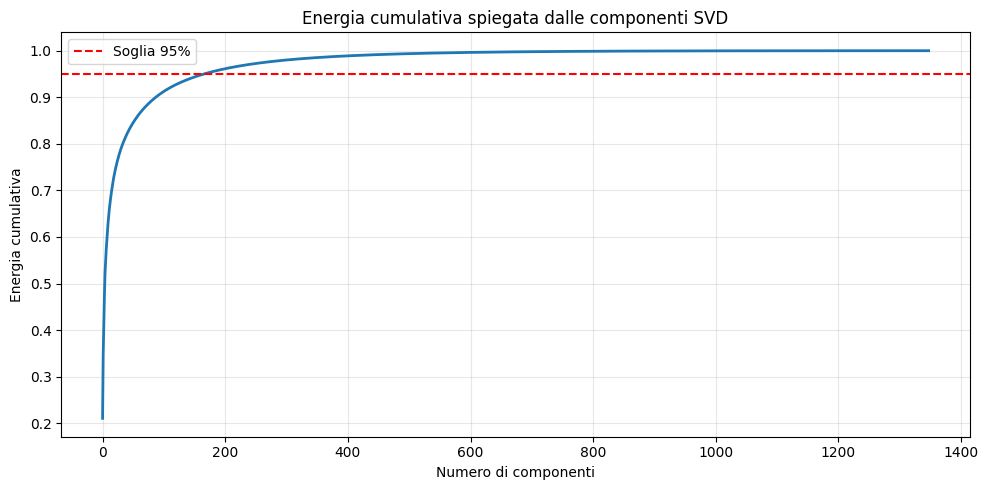

In [9]:
# Energia cumulativa
viz.plot_cumulative_energy(energy)

In [10]:
# Riduzione dimensionale
start_time = time.time()
X_reduced = svd_reducer.fit_transform(dataset.X_centered)
execution_times['dimensionality_reduction'] = time.time() - start_time

print(f"Shape dati ridotti: {X_reduced.shape}")
print(f"Tempo riduzione: {execution_times['dimensionality_reduction']:.4f}s")
print(f"Throughput: {len(X_reduced)/execution_times['dimensionality_reduction']:.1f} samples/s")

Shape dati ridotti: (1348, 167)
Tempo riduzione: 0.4053s
Throughput: 3325.6 samples/s


## 6. Ricostruzione e Analisi Qualità

In [11]:
# Ricostruzione volti
start_time = time.time()
X_reconstructed = svd_reducer.reconstruct_face(X_reduced, dataset.mean_face)
execution_times['reconstruction'] = time.time() - start_time

print(f"Tempo ricostruzione: {execution_times['reconstruction']:.4f}s")

Tempo ricostruzione: 0.0191s


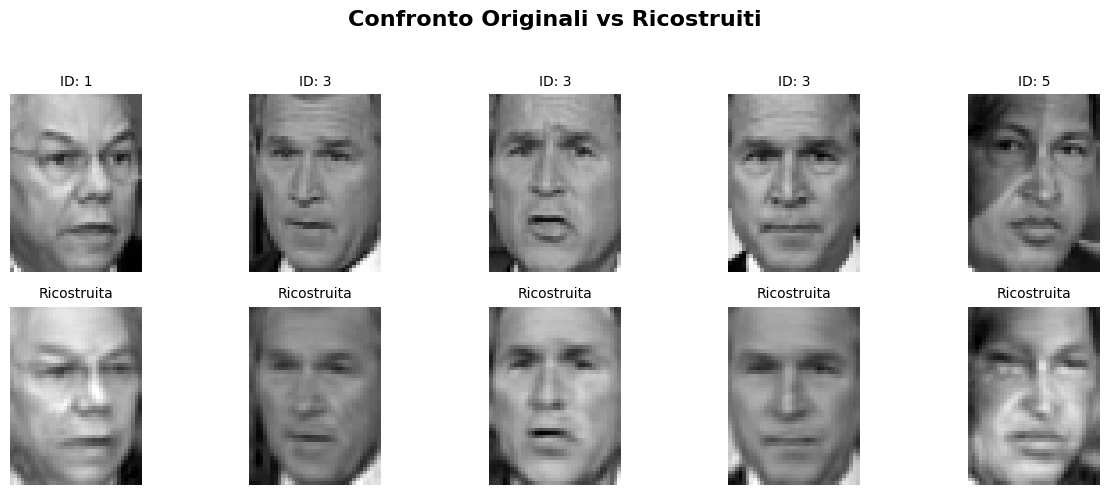

In [12]:
# Visualizza originali vs ricostruiti
viz.plot_original_vs_reconstructed_lfw(dataset.X_flat, X_reconstructed, dataset.y, dataset.X)

QUALITÀ RICOSTRUZIONE
MSE medio: 0.001104
Deviazione standard MSE: 0.000369
MSE minimo: 0.000259
MSE massimo: 0.002852
MSE mediano: 0.001069

95° percentile MSE: 0.001782
PSNR medio: 29.57 dB
Deviazione standard MSE: 3.688845e-04


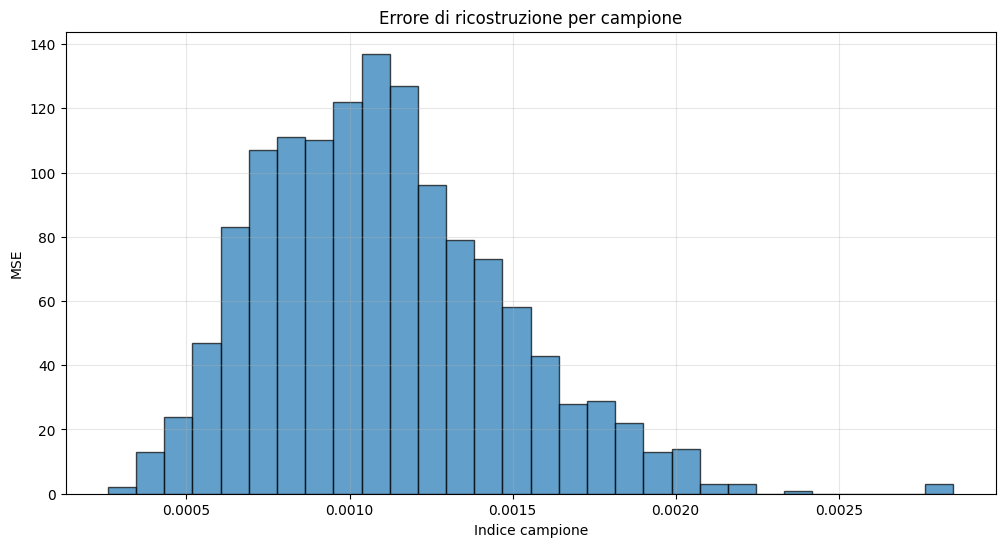

In [13]:
# Analisi errore di ricostruzione
mse_per_sample = np.mean((dataset.X_flat - X_reconstructed) ** 2, axis=1)
mean_mse = np.mean(mse_per_sample)
std_mse = np.std(mse_per_sample)

print("=" * 60)
print("QUALITÀ RICOSTRUZIONE")
print("=" * 60)
print(f"MSE medio: {mean_mse:.6f}")
print(f"Deviazione standard MSE: {std_mse:.6f}")
print(f"MSE minimo: {np.min(mse_per_sample):.6f}")
print(f"MSE massimo: {np.max(mse_per_sample):.6f}")
print(f"MSE mediano: {np.median(mse_per_sample):.6f}")
print(f"\n95° percentile MSE: {np.percentile(mse_per_sample, 95):.6f}")
print(f"PSNR medio: {10 * np.log10(1.0 / mean_mse):.2f} dB")
print("=" * 60)

performance_metrics['reconstruction_mse'] = mean_mse

viz.plot_reconstruction_error(mse_per_sample)

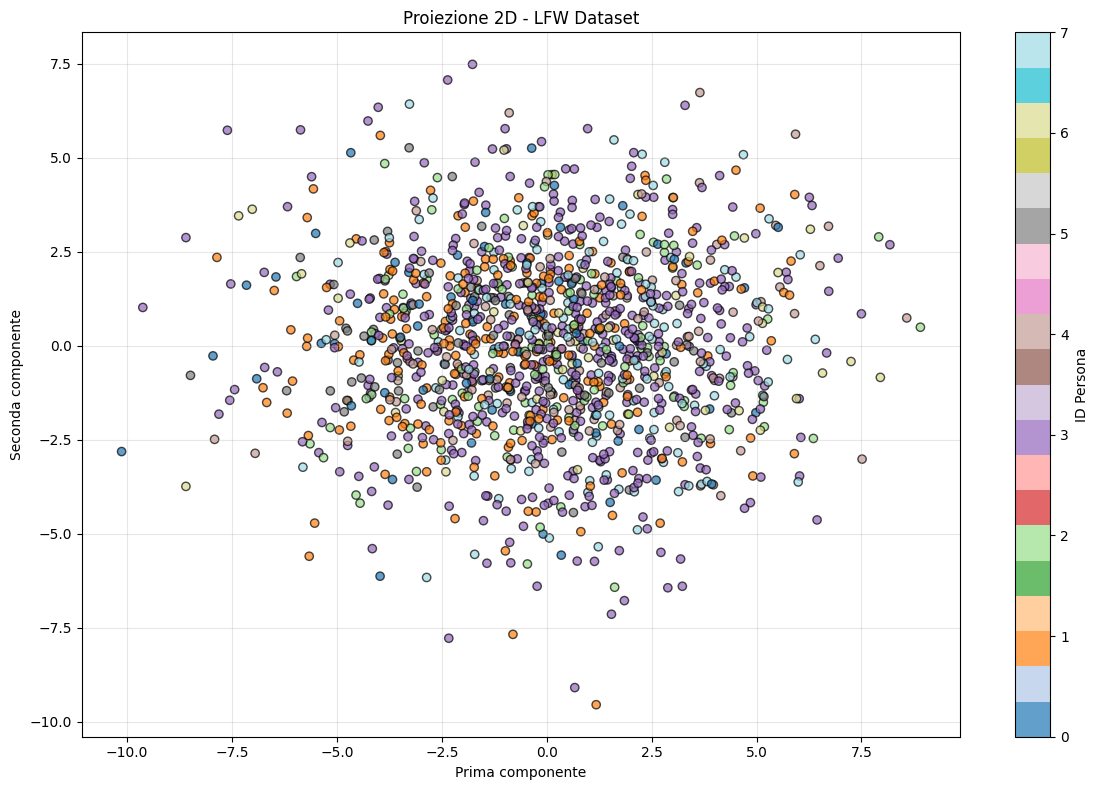

In [14]:
# Proiezione 2D
viz.plot_2d_projection(X_reduced, dataset.y, 
                       title="Proiezione 2D - LFW Dataset")

## 7. Split Train/Test

In [15]:
X_train, X_test, y_train, y_test = dataset.dataset_splitting(X_reduced)

print("=" * 60)
print("SPLIT TRAIN/TEST")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} campioni ({(1-dataset.test_size)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} campioni ({dataset.test_size*100:.0f}%)")
print(f"Features per campione: {X_train.shape[1]}")
print(f"\nDistribuzione classi:")
print(f"  Training: {len(np.unique(y_train))} persone")
print(f"  Test: {len(np.unique(y_test))} persone")
print(f"\nRapporto training/test samples: {len(X_train)/len(X_test):.2f}")
print("=" * 60)

SPLIT TRAIN/TEST
Training set: 1011 campioni (75%)
Test set: 337 campioni (25%)
Features per campione: 167

Distribuzione classi:
  Training: 8 persone
  Test: 8 persone

Rapporto training/test samples: 3.00


## 8. Benchmark Classificatori

Confronto sistematico tra KNN e diverse varianti di SVM.

In [16]:
print("\n" + "=" * 60)
print("BENCHMARK CLASSIFICATORI SU LFW")
print("=" * 60)

results = {}


BENCHMARK CLASSIFICATORI SU LFW


### 8.1 K-Nearest Neighbors

In [17]:
print("\nTraining KNN...")
start_time = time.time()
recognizer = FaceRecognizer(n_neighbors=1, unknown_threshold=0.5)
recognizer.train_knn(X_train, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred_knn = recognizer.evaluate_knn(X_test, y_test)
predict_time = time.time() - start_time

knn_time = train_time + predict_time
knn_acc = accuracy_score(y_test, y_pred_knn)

results['KNN'] = {
    'accuracy': knn_acc,
    'train_time': train_time,
    'predict_time': predict_time,
    'total_time': knn_time,
    'predictions': y_pred_knn
}

print(f"\nKNN Completato")
print(f"   Accuracy: {knn_acc * 100:.2f}%")
print(f"   Training time: {train_time:.4f}s")
print(f"   Prediction time: {predict_time:.4f}s ({len(X_test)/predict_time:.1f} samples/s)")
print(f"   Errori: {np.sum(y_pred_knn != y_test)}/{len(y_test)}")


Training KNN...

KNN Completato
   Accuracy: 62.02%
   Training time: 0.0000s
   Prediction time: 1.4882s (226.4 samples/s)
   Errori: 128/337


### 8.2 SVM Lineare

In [19]:
print("\nTraining SVM Lineare...")
start_time = time.time()
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred_svm_lin = svm_linear.predict(X_test)
predict_time = time.time() - start_time

lin_time = train_time + predict_time
lin_acc = accuracy_score(y_test, y_pred_svm_lin)

results['SVM Linear'] = {
    'accuracy': lin_acc,
    'train_time': train_time,
    'predict_time': predict_time,
    'total_time': lin_time,
    'predictions': y_pred_svm_lin
}

print(f"\nSVM Lineare Completato")
print(f"   Accuracy: {lin_acc * 100:.2f}%")
print(f"   Training time: {train_time:.4f}s")
print(f"   Errori: {np.sum(y_pred_svm_lin != y_test)}/{len(y_test)}")


Training SVM Lineare...

SVM Lineare Completato
   Accuracy: 81.01%
   Training time: 0.0629s
   Errori: 64/337


### 8.3 SVM RBF

In [21]:
print("\nTraining SVM RBF...")
start_time = time.time()
svm_rbf = SVC(kernel='rbf', C=10, gamma='scale')
svm_rbf.fit(X_train, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred_svm_rbf = svm_rbf.predict(X_test)
predict_time = time.time() - start_time

rbf_time = train_time + predict_time
rbf_acc = accuracy_score(y_test, y_pred_svm_rbf)

results['SVM RBF'] = {
    'accuracy': rbf_acc,
    'train_time': train_time,
    'predict_time': predict_time,
    'total_time': rbf_time,
    'predictions': y_pred_svm_rbf
}

print(f"\nSVM RBF Completato")
print(f"   Accuracy: {rbf_acc * 100:.2f}%")
print(f"   Training time: {train_time:.4f}s")
print(f"   Prediction time: {predict_time:.4f}s ({len(X_test)/predict_time:.1f} samples/s)")
print(f"   Errori: {np.sum(y_pred_svm_rbf != y_test)}/{len(y_test)}")


Training SVM RBF...

SVM RBF Completato
   Accuracy: 79.82%
   Training time: 0.1027s
   Prediction time: 0.0503s (6704.7 samples/s)
   Errori: 68/337


### 8.4 Grid Search - Ottimizzazione Automatica

In [23]:
print("\n" + "=" * 60)
print("GRID SEARCH - OTTIMIZZAZIONE IPERPARAMETRI")
print("=" * 60)
print("Testando 16 combinazioni di parametri con 5-fold CV...\n")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

start_time = time.time()
grid.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Grid Search Completata")
print(f"{'='*60}")
print(f"Migliori parametri: {grid.best_params_}")
print(f"Migliore CV accuracy: {grid.best_score_:.4f}")
print(f"Tempo totale: {grid_time:.2f}s ({grid_time/60:.1f} minuti)")
print(f"Tempo medio per fit: {grid_time/len(grid.cv_results_['params']):.2f}s")

# Test set evaluation
best_svm = grid.best_estimator_
start_time = time.time()
y_pred_best = best_svm.predict(X_test)
predict_time = time.time() - start_time
best_acc = accuracy_score(y_test, y_pred_best)

results['SVM Best'] = {
    'accuracy': best_acc,
    'train_time': grid_time,
    'predict_time': predict_time,
    'total_time': grid_time + predict_time,
    'predictions': y_pred_best,
    'params': grid.best_params_,
    'cv_score': grid.best_score_
}

print(f"\nTest Set Performance:")
print(f"   Accuracy: {best_acc * 100:.2f}%")
print(f"   Errori: {np.sum(y_pred_best != y_test)}/{len(y_test)}")
print(f"   Prediction time: {predict_time:.4f}s")
print("=" * 60)


GRID SEARCH - OTTIMIZZAZIONE IPERPARAMETRI
Testando 16 combinazioni di parametri con 5-fold CV...

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Grid Search Completata
Migliori parametri: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Migliore CV accuracy: 0.8151
Tempo totale: 1.16s (0.0 minuti)
Tempo medio per fit: 0.07s

Test Set Performance:
   Accuracy: 80.42%
   Errori: 66/337
   Prediction time: 0.0157s


In [24]:
# Analisi Support Vectors
print("\n" + "=" * 60)
print("ANALISI SUPPORT VECTORS")
print("=" * 60)
print(f"Totale Support Vectors: {np.sum(best_svm.n_support_)}")
print(f"Percentuale del training set: {np.sum(best_svm.n_support_)/len(X_train)*100:.1f}%")
print(f"\nDistribuzione per classe (top 10):")
for i, n_sv in enumerate(sorted(best_svm.n_support_, reverse=True)[:10]):
    print(f"  Classe {i+1}: {n_sv} support vectors")
print(f"\nMedia SV per classe: {np.mean(best_svm.n_support_):.1f}")
print(f"Mediana SV per classe: {np.median(best_svm.n_support_):.1f}")
print("=" * 60)


ANALISI SUPPORT VECTORS
Totale Support Vectors: 701
Percentuale del training set: 69.3%

Distribuzione per classe (top 10):
  Classe 1: 208 support vectors
  Classe 2: 127 support vectors
  Classe 3: 82 support vectors
  Classe 4: 76 support vectors
  Classe 5: 71 support vectors
  Classe 6: 53 support vectors
  Classe 7: 47 support vectors
  Classe 8: 37 support vectors

Media SV per classe: 87.6
Mediana SV per classe: 73.5


## 9. Analisi Comparativa Performance

In [26]:
# Tabella comparativa
print("\n" + "=" * 80)
print("CONFRONTO FINALE MODELLI - LFW DATASET")
print("=" * 80)
print(f"{'Modello':<15} {'Accuracy':<12} {'Train (s)':<12} {'Predict (s)':<12} {'Errori'}")
print("-" * 80)

for model_name, metrics in results.items():
    errors = np.sum(metrics['predictions'] != y_test)
    print(f"{model_name:<15} {metrics['accuracy']*100:>6.2f}%      "
          f"{metrics['train_time']:>9.4f}    "
          f"{metrics['predict_time']:>9.4f}     "
          f"{errors}/{len(y_test)}")

print("=" * 80)

# Identifica il miglior modello
best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
fastest_model = min(results.items(), key=lambda x: x[1]['total_time'])

print(f"\nMIGLIOR ACCURACY: {best_model[0]}")
print(f"   {best_model[1]['accuracy']*100:.2f}% accuracy")
print(f"   {best_model[1]['total_time']:.4f}s tempo totale")

print(f"\nPIÙ VELOCE: {fastest_model[0]}")
print(f"   {fastest_model[1]['accuracy']*100:.2f}% accuracy")
print(f"   {fastest_model[1]['total_time']:.4f}s tempo totale")

# Performance metrics
performance_metrics['best_accuracy'] = best_model[1]['accuracy']
performance_metrics['best_model'] = best_model[0]


CONFRONTO FINALE MODELLI - LFW DATASET
Modello         Accuracy     Train (s)    Predict (s)  Errori
--------------------------------------------------------------------------------
KNN              62.02%         0.0000       1.4882     128/337
SVM Linear       81.01%         0.0629       0.0158     64/337
SVM RBF          79.82%         0.1027       0.0503     68/337
SVM Best         80.42%         1.1607       0.0157     66/337

MIGLIOR ACCURACY: SVM Linear
   81.01% accuracy
   0.0787s tempo totale

PIÙ VELOCE: SVM Linear
   81.01% accuracy
   0.0787s tempo totale


In [27]:
# Classification Report dettagliato
print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT - {best_model[0]}")
print("=" * 60)
print(classification_report(y_test, best_model[1]['predictions']))

report = classification_report(y_test, best_model[1]['predictions'], output_dict=True)
viz.save_excel(report, "svm_report.xlsx")


CLASSIFICATION REPORT - SVM Linear
              precision    recall  f1-score   support

           0       0.59      0.67      0.62        15
           1       0.83      0.85      0.84        68
           2       0.77      0.74      0.75        31
           3       0.89      0.83      0.86       126
           4       0.60      0.78      0.68        23
           5       1.00      0.60      0.75        20
           6       0.86      1.00      0.92        12
           7       0.76      0.83      0.80        42

    accuracy                           0.81       337
   macro avg       0.79      0.79      0.78       337
weighted avg       0.82      0.81      0.81       337



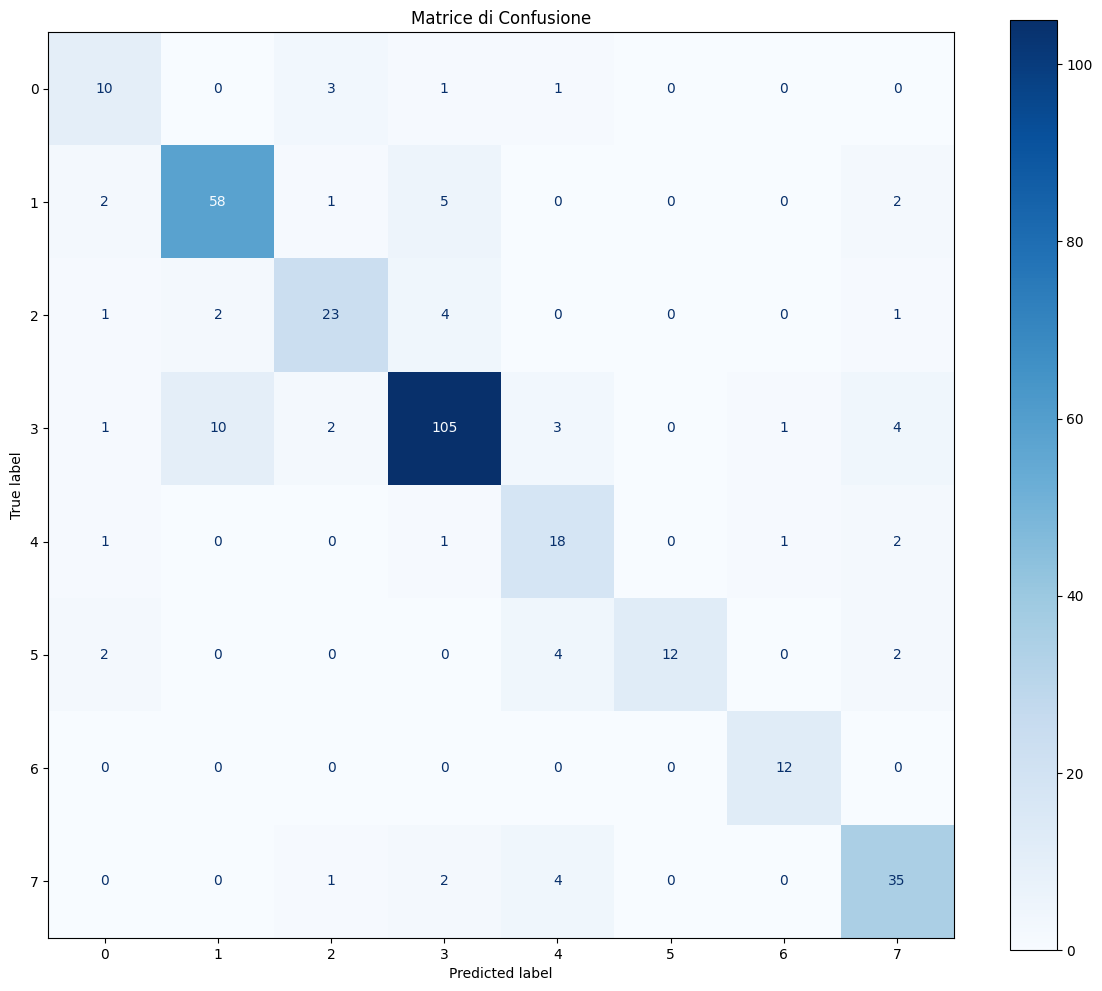

In [28]:
# Matrice di confusione
viz.plot_confusion_matrix(y_test, best_model[1]['predictions'])

In [33]:
# Salva risultati
comparison = {
    "Model": list(results.keys()),
    "Accuracy": [r['accuracy'] for r in results.values()],
    "Train_Time": [r['train_time'] for r in results.values()],
    "Predict_Time": [r['predict_time'] for r in results.values()],
    "Total_Time": [r['total_time'] for r in results.values()]
}
# Creazione del DataFrame
df = pd.DataFrame(comparison)

# Stampa della tabella
print(df.to_string(index=False))

     Model  Accuracy  Train_Time  Predict_Time  Total_Time
       KNN  0.620178    0.000000      1.488219    1.488219
SVM Linear  0.810089    0.062923      0.015782    0.078705
   SVM RBF  0.798220    0.102661      0.050263    0.152924
  SVM Best  0.804154    1.160692      0.015724    1.176416


## 10. Analisi Distanze e Unknown Detection

In [34]:
# Calcola distanze
print("Calcolo distanze...")
distances_train = recognizer.compute_min_distances(X_train, X_train)
distances_test = recognizer.compute_min_distances(X_test, X_train)

print("\n" + "=" * 60)
print("ANALISI DISTANZE - LFW")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  Range: [{np.min(distances_train):.4f}, {np.max(distances_train):.4f}]")
print(f"  Media: {np.mean(distances_train):.4f} ± {np.std(distances_train):.4f}")
print(f"  Mediana: {np.median(distances_train):.4f}")
print(f"  Percentili: 25%={np.percentile(distances_train, 25):.4f}, "
      f"75%={np.percentile(distances_train, 75):.4f}, "
      f"95%={np.percentile(distances_train, 95):.4f}")

print(f"\nTest Set:")
print(f"  Range: [{np.min(distances_test):.4f}, {np.max(distances_test):.4f}]")
print(f"  Media: {np.mean(distances_test):.4f} ± {np.std(distances_test):.4f}")
print(f"  Mediana: {np.median(distances_test):.4f}")
print(f"  Percentili: 25%={np.percentile(distances_test, 25):.4f}, "
      f"75%={np.percentile(distances_test, 75):.4f}, "
      f"95%={np.percentile(distances_test, 95):.4f}")
print("=" * 60)

Calcolo distanze...

ANALISI DISTANZE - LFW

Training Set:
  Range: [0.0000, 0.0000]
  Media: 0.0000 ± 0.0000
  Mediana: 0.0000
  Percentili: 25%=0.0000, 75%=0.0000, 95%=0.0000

Test Set:
  Range: [1.0807, 9.2150]
  Media: 4.8035 ± 1.0057
  Mediana: 4.7354
  Percentili: 25%=4.1063, 75%=5.4039, 95%=6.3808


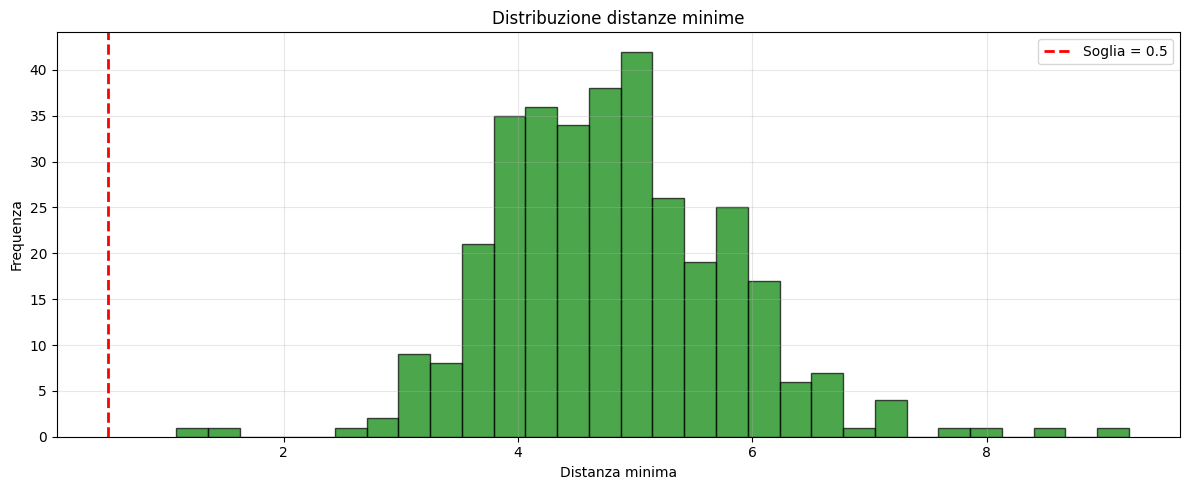

In [35]:
# Visualizza distribuzione
viz.plot_distance_distribution(distances_test, recognizer.unknown_threshold)

In [36]:
# Ottimizza soglia
threshold_info = recognizer.optimize_unknown_threshold(X_train, X_test)

print("\n" + "=" * 60)
print("OTTIMIZZAZIONE SOGLIA UNKNOWN DETECTION")
print("=" * 60)
print(f"Soglia precedente: {0.5:.4f}")
print(f"Soglia ottimale (95° percentile): {threshold_info['optimal_threshold']:.4f}")
print(f"Incremento: {(threshold_info['optimal_threshold']/0.5 - 1)*100:.1f}%")
print(f"\nStatistiche distanze:")
for key, value in threshold_info['distance_stats'].items():
    print(f"  {key}: {value:.4f}")
print("=" * 60)

performance_metrics['unknown_threshold'] = threshold_info['optimal_threshold']


OTTIMIZZAZIONE SOGLIA UNKNOWN DETECTION
Soglia precedente: 0.5000
Soglia ottimale (95° percentile): 6.3808
Incremento: 1176.2%

Statistiche distanze:
  mean: 4.8035
  std: 1.0057
  median: 4.7354
  p95: 6.3808


## 11. Cross-Validation e Robustezza

In [37]:
# Cross-validation
print("Esecuzione 5-fold cross-validation...\n")
cv_results = recognizer.cross_validate(X_train, y_train, cv=5)

print("=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"Mean Accuracy: {cv_results['mean_accuracy']:.4f}")
print(f"Std Accuracy: {cv_results['std_accuracy']:.4f}")
print(f"Coefficient of Variation: {cv_results['std_accuracy']/cv_results['mean_accuracy']*100:.2f}%")
print(f"\nConfidence Interval (95%):")
print(f"  [{cv_results['confidence_interval inf']:.4f}, {cv_results['confidence_interval sup']:.4f}]")
print(f"\nScores per fold:")
for i, score in enumerate(cv_results['all_scores'], 1):
    print(f"  Fold {i}: {score:.4f}")
print("=" * 60)

viz.save_excel([cv_results], 'cross_validation_results.xlsx')

Esecuzione 5-fold cross-validation...

CROSS-VALIDATION RESULTS
Mean Accuracy: 0.6211
Std Accuracy: 0.0282
Coefficient of Variation: 4.54%

Confidence Interval (95%):
  [0.5647, 0.6776]

Scores per fold:
  Fold 1: 0.6453
  Fold 2: 0.5743
  Fold 3: 0.6535
  Fold 4: 0.6238
  Fold 5: 0.6089


## 12. Analisi Errori

In [39]:
# Analisi errori
y_pred_analysis = recognizer.evaluate_knn(X_test, y_test)
errors = recognizer.analyze_misclassifications(X_test, y_test, y_pred_analysis)

print("\n" + "=" * 60)
print("ANALISI ERRORI DI CLASSIFICAZIONE")
print("=" * 60)
print(f"Totale campioni test: {len(y_test)}")
print(f"Errori totali: {len(errors['misclassified_samples'])}")
print(f"Error rate: {len(errors['misclassified_samples'])/len(y_test)*100:.2f}%")

if len(errors['misclassified_samples']) > 0:
    print(f"\nPrimi 5 errori:")
    for i, e in enumerate(errors['misclassified_samples'][:5], 1):
        print(f"  {i}. Sample {e['index']}: "
              f"True={e['true_label']}, Pred={e['predicted_label']}, "
              f"Distance={e['nearest_distance']:.4f}")
    
    print(f"\nCoppie più confuse (top 5):")
    for (true_lbl, pred_lbl), count in errors['most_confused_pairs']:
        print(f"  Classe {true_lbl} → Classe {pred_lbl}: {count} volte")
else:
    print("\nNessun errore di classificazione!")
    
print("=" * 60)


ANALISI ERRORI DI CLASSIFICAZIONE
Totale campioni test: 337
Errori totali: 128
Error rate: 37.98%

Primi 5 errori:
  1. Sample 0: True=3, Pred=2, Distance=38.2378
  2. Sample 1: True=4, Pred=3, Distance=45.0041
  3. Sample 9: True=1, Pred=3, Distance=47.7730
  4. Sample 11: True=3, Pred=1, Distance=34.4030
  5. Sample 12: True=0, Pred=4, Distance=62.3094

Coppie più confuse (top 5):
  Classe 2 → Classe 3: 13 volte
  Classe 3 → Classe 2: 12 volte
  Classe 1 → Classe 3: 11 volte
  Classe 4 → Classe 3: 8 volte
  Classe 7 → Classe 3: 8 volte


## 13. Riepilogo Performance e Confronto

In [41]:
# Calcola tempo totale
total_execution_time = sum(execution_times.values())

print("\n" + "=" * 80)
print(" " * 25 + "RIEPILOGO FINALE - LFW DATASET")
print("=" * 80)

print("\nDATASET:")
print(f"   Nome: Labeled Faces in the Wild (LFW)")
print(f"   Immagini totali: {len(dataset.y)}")
print(f"   Persone uniche: {len(np.unique(dataset.y))}")
print(f"   Risoluzione: {dataset.X.shape[1]}x{dataset.X.shape[2]} pixels")
print(f"   Immagini/persona: min={np.min(counts)}, max={np.max(counts)}, media={np.mean(counts):.1f}")

print("\nRIDUZIONE DIMENSIONALE (SVD):")
print(f"   Dimensioni originali: {dataset.X_flat.shape[1]} features")
print(f"   Componenti SVD: {n_components} ({svd_reducer.energy_threshold*100}% energia)")
print(f"   Compressione: {dataset.X_flat.shape[1]/n_components:.2f}x")
print(f"   Riduzione: {(1-n_components/dataset.X_flat.shape[1])*100:.1f}%")
print(f"   MSE ricostruzione: {mean_mse:.6f}")

print("\nCLASSIFICAZIONE:")
print(f"   Miglior modello: {best_model[0]}")
if 'params' in best_model[1]:
    print(f"   Parametri: {best_model[1]['params']}")
print(f"   Test Accuracy: {best_model[1]['accuracy']*100:.2f}%")
print(f"   Errori: {np.sum(best_model[1]['predictions'] != y_test)}/{len(y_test)}")
print(f"   Tempo training: {best_model[1]['train_time']:.2f}s")
print(f"   Tempo predizione: {best_model[1]['predict_time']:.4f}s")
print(f"   Throughput: {len(X_test)/best_model[1]['predict_time']:.1f} samples/s")

print("\nUNKNOWN DETECTION:")
print(f"   Soglia ottimale: {recognizer.unknown_threshold:.4f}")
print(f"   Basata su: 95° percentile delle distanze")
print(f"   Range distanze test: [{np.min(distances_test):.4f}, {np.max(distances_test):.4f}]")

print("\nBREAKDOWN TEMPI:")
for step, time_val in execution_times.items():
    percentage = (time_val / total_execution_time) * 100
    print(f"   {step:.<35} {time_val:>8.4f}s ({percentage:>5.1f}%)")
print(f"   {'TOTALE':.<35} {total_execution_time:>8.2f}s (100.0%)")

print("\nCONFRONTO MODELLI:")
for model_name, metrics in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print(f"   {model_name:.<20} {metrics['accuracy']*100:>6.2f}%  "
          f"(train: {metrics['train_time']:>7.3f}s, predict: {metrics['predict_time']:>7.4f}s)")

print("\n" + "=" * 80)
print(" " * 30 + "ANALISI COMPLETATA")
print("=" * 80 + "\n")


                         RIEPILOGO FINALE - LFW DATASET

DATASET:
   Nome: Labeled Faces in the Wild (LFW)
   Immagini totali: 1348
   Persone uniche: 8
   Risoluzione: 50x37 pixels
   Immagini/persona: min=60, max=530, media=168.5

RIDUZIONE DIMENSIONALE (SVD):
   Dimensioni originali: 1850 features
   Componenti SVD: 167 (95.0% energia)
   Compressione: 11.08x
   Riduzione: 91.0%
   MSE ricostruzione: 0.001104

CLASSIFICAZIONE:
   Miglior modello: SVM Linear
   Test Accuracy: 81.01%
   Errori: 64/337
   Tempo training: 0.06s
   Tempo predizione: 0.0158s
   Throughput: 21353.0 samples/s

UNKNOWN DETECTION:
   Soglia ottimale: 6.3808
   Basata su: 95° percentile delle distanze
   Range distanze test: [1.0807, 9.2150]

BREAKDOWN TEMPI:
   TOTALE.............................     0.00s (100.0%)

CONFRONTO MODELLI:
   SVM Linear..........  81.01%  (train:   0.063s, predict:  0.0158s)
   SVM Best............  80.42%  (train:   1.161s, predict:  0.0157s)
   SVM RBF.............  79.82%  (tr

## 14. Confronto LFW vs Olivetti

**Note comparative:**

| Metrica | Olivetti | LFW | Note |
|---------|----------|-----|------|
| Dataset size | 400 images, 40 persone | 1000+ images, varie persone | LFW molto più grande |
| Complessità | Controllato, sfondo uniforme | Wild, condizioni reali | LFW più difficile |
| Risoluzione | 64x64 (4096 features) | Variabile (resize 0.4) | LFW richiede più preprocessing |
| Accuracy attesa | 95-100% | 80-95% | LFW naturalmente più basso |
| Tempo SVD | <1s | 5-20s | LFW richiede più computazione |
| Componenti SVD | ~50-100 | ~100-200 | LFW più variabilità |

---

## Conclusioni

### Performance su LFW:
1. **SVD efficace** anche su dati complessi, ma richiede più componenti
2. **SVM RBF** tende a performare meglio di KNN su dati reali
3. **Grid Search** essenziale per ottimizzare su dati wild
4. **Tempo computazionale** significativamente più alto rispetto a Olivetti
5. **Accuracy** più bassa ma accettabile data la complessità

### Limitazioni:
- Sensibile a illuminazione e pose estreme
- Richiede soglia unknown più alta
- Tempo di training più lungo

### Possibili Miglioramenti:
- Data augmentation per aumentare robustezza
- Preprocessing più sofisticato (alignment, normalizzazione)
- Ensemble di classificatori
- Deep learning per feature extraction